In [38]:
import pandas as pd
from datetime import datetime

# =========================
# CONFIG
# =========================
TIME_FORMAT = "%H:%M"
START_DAY = "07:00"
END_DAY = "17:30"
SLOT_INTERVAL = "60min"

# =========================
# 1. LOAD & VALIDATE
# =========================
def load_data(path):
    df = pd.read_csv(path)

    required_cols = [
        'student_id', 'student_name', 'day',
        'start_time', 'end_time', 'course', 'major'
    ]

    missing = set(required_cols) - set(df.columns)
    if missing:
        raise ValueError(f"Missing columns: {missing}")

    return df

# =========================
# 2. PREPROCESSING
# =========================
def preprocess(df):
    df = df.copy()

    # ✅ FIX: parse ke datetime lalu ambil .time() aja
    # supaya ga ada komponen tanggal yang bisa bikin comparison meleset
    df['start_time'] = pd.to_datetime(
        df['start_time'], format=TIME_FORMAT, errors='coerce'
    ).dt.time

    df['end_time'] = pd.to_datetime(
        df['end_time'], format=TIME_FORMAT, errors='coerce'
    ).dt.time

    # drop invalid rows
    df = df.dropna(subset=['start_time', 'end_time'])

    # normalize day
    df['day'] = df['day'].str.capitalize()

    return df

# =========================
# 3. GENERATE TIME SLOTS
# =========================
def generate_slots():
    time_range = pd.date_range(
        start=f"2000-01-01 {START_DAY}",
        end=f"2000-01-01 {END_DAY}",
        freq=SLOT_INTERVAL
    )
    days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]

    slots = []
    for day in days:
        for i in range(len(time_range) - 1):
            slots.append({
                "day": day,
                # ✅ FIX: ambil .time() juga biar apple-to-apple
                "slot_start": time_range[i].time(),
                "slot_end": time_range[i + 1].time()
            })

    return pd.DataFrame(slots)

# =========================
# 4. CONFLICT LOGIC
# =========================
def is_conflict(slot_start, slot_end, class_start, class_end):
    # semua sudah datetime.time → comparison aman
    return (slot_start < class_end) and (slot_end > class_start)

# =========================
# 5. ANALYSIS ENGINE
# =========================
def analyze_conflicts(df, slots_df):
    total_students = df['student_id'].nunique()
    results = []

    for _, slot in slots_df.iterrows():
        df_day = df[df['day'] == slot['day']]

        conflict_students = set()

        for _, row in df_day.iterrows():
            if is_conflict(
                slot['slot_start'],
                slot['slot_end'],
                row['start_time'],
                row['end_time']
            ):
                conflict_students.add(row['student_id'])

        conflict_count = len(conflict_students)
        free_count = total_students - conflict_count
        free_ratio = free_count / total_students

        results.append({
            "day": slot['day'],
            "slot": f"{slot['slot_start']} - {slot['slot_end']}",
            "conflict": conflict_count,
            "free": free_count,
            "free_ratio": round(free_ratio, 2)
        })

    result_df = pd.DataFrame(results)
    return result_df.sort_values(
        by=["conflict", "free_ratio"],
        ascending=[True, False]
    ).reset_index(drop=True)

# =========================
# 6. MAIN PIPELINE
# =========================
def run_analysis(path):
    df = load_data(path)
    df = preprocess(df)
    slots_df = generate_slots()
    result = analyze_conflicts(df, slots_df)
    return result

# =========================
# EXECUTE
# =========================
result_df = run_analysis("./data/jadwal_mahasiswa.csv")
result_df

,day,slot,conflict,free,free_ratio
0,Thursday,12:00:00 - 13:00:00,0,10,1.0
1,Monday,16:00:00 - 17:00:00,1,9,0.9
2,Tuesday,16:00:00 - 17:00:00,1,9,0.9
3,Thursday,07:00:00 - 08:00:00,1,9,0.9
4,Thursday,08:00:00 - 09:00:00,1,9,0.9
5,Friday,13:00:00 - 14:00:00,1,9,0.9
6,Friday,14:00:00 - 15:00:00,1,9,0.9
7,Friday,16:00:00 - 17:00:00,1,9,0.9
8,Monday,12:00:00 - 13:00:00,2,8,0.8
9,Tuesday,12:00:00 - 13:00:00,2,8,0.8


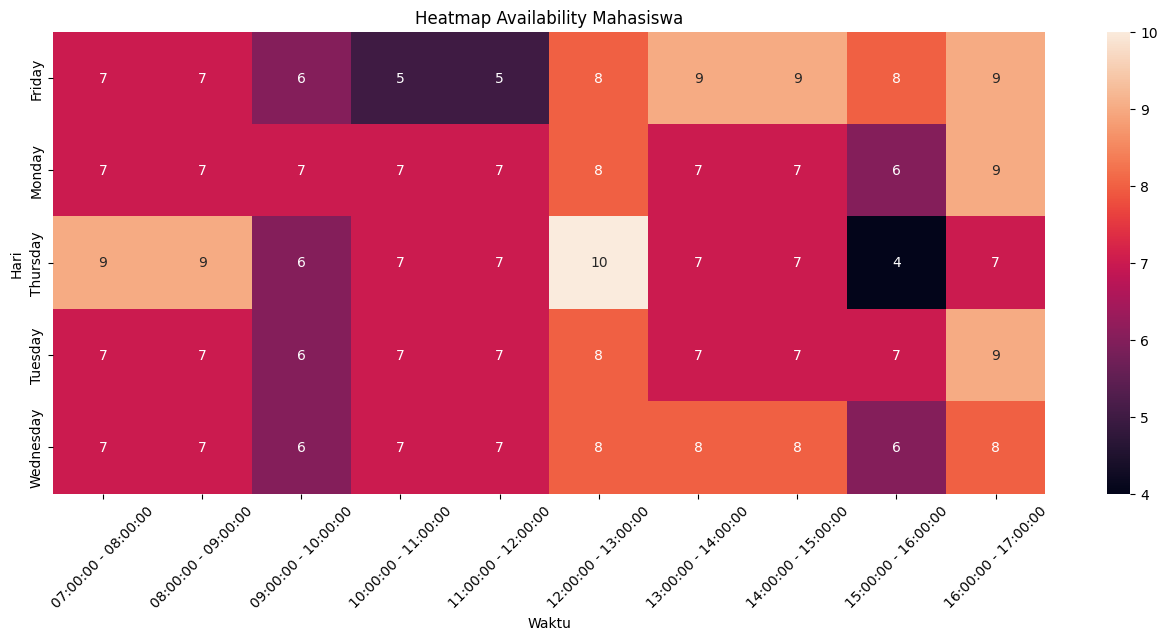

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

pivot = result_df.pivot(index="day", columns="slot", values="free")

plt.figure(figsize=(16,6))
sns.heatmap(pivot, annot=True, fmt=".0f")
plt.title("Heatmap Availability Mahasiswa")
plt.xlabel("Waktu")
plt.ylabel("Hari")
plt.xticks(rotation=45)
plt.show()